In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [125]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [126]:
import torch
import arviz as az
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from tqdm import tqdm

from seisfwi.model import AcousticModel, RockPhysicsGassmann
from seisfwi.survey import SeismicData
from seisfwi.utils import plot_misfit, load_log_file
import seisfwi.defaults as defaults

from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings, plot_2d
from utils.project_utils import rockphysic_inversion
from utils import RockPhysicsModel

from HMC_FWI_VAE import get_survey

In [127]:
configure_plot_settings()
cmap_range     = {'vp': (1400, 4500)}
cmap_range_co2 = {'vp': (-125,  125)}

In [128]:
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 

In [129]:
src_id = 3
rec_id = 1
f0 = 30          # 60
noise_flag= ""   #"-noise-30dB"

path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id}-geophone-{rec_id}-{f0}Hz{noise_flag}")
path

PosixPath('/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-3-geophone-1-30Hz')

In [130]:
model_bl, model_ml, survey = get_survey(f0 = f0, src_id=src_id, rec_id=rec_id, vp_ml_file = f'model/vp_ml_nz346_nx401_5m.npy')
model_fwi = AcousticModel.load(path/"Model-FWI.npz")
sa_fwi = np.load(path/"Model-FWI-Sat.npy").reshape(15, 179)

# vp_bl = np.load('model/vp_bl_fwi_nz346_nx401_5m.npy')        
vp_bl = model_bl.get_model('vp')
vp_ml = model_ml.get_model('vp')
vp_fwi = model_fwi.get_model('vp') - vp_bl
vp_obs = vp_ml - model_bl.get_model('vp')

vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
vp_obs = vp_obs[nz0:nz0+nz_res, nx0:nx0+nx_res]

# x, z = model_bl.x, model_bl.z

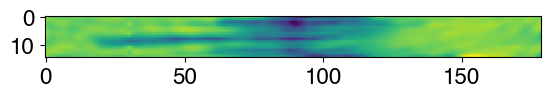

In [131]:
plt.imshow(vp_fwi)

### Rock physics inversion

In [132]:
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [133]:
sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=True)

Iteration 0001/100: Loss = 7354.58
Iteration 0011/100: Loss = 2917.25
Iteration 0021/100: Loss = 954.22
Iteration 0031/100: Loss = 338.35
Iteration 0041/100: Loss = 185.81
Iteration 0051/100: Loss = 142.51
Iteration 0061/100: Loss = 127.51
Iteration 0071/100: Loss = 122.51
Iteration 0081/100: Loss = 120.73
Iteration 0091/100: Loss = 120.01
Iteration 0100/100: Loss = 119.74


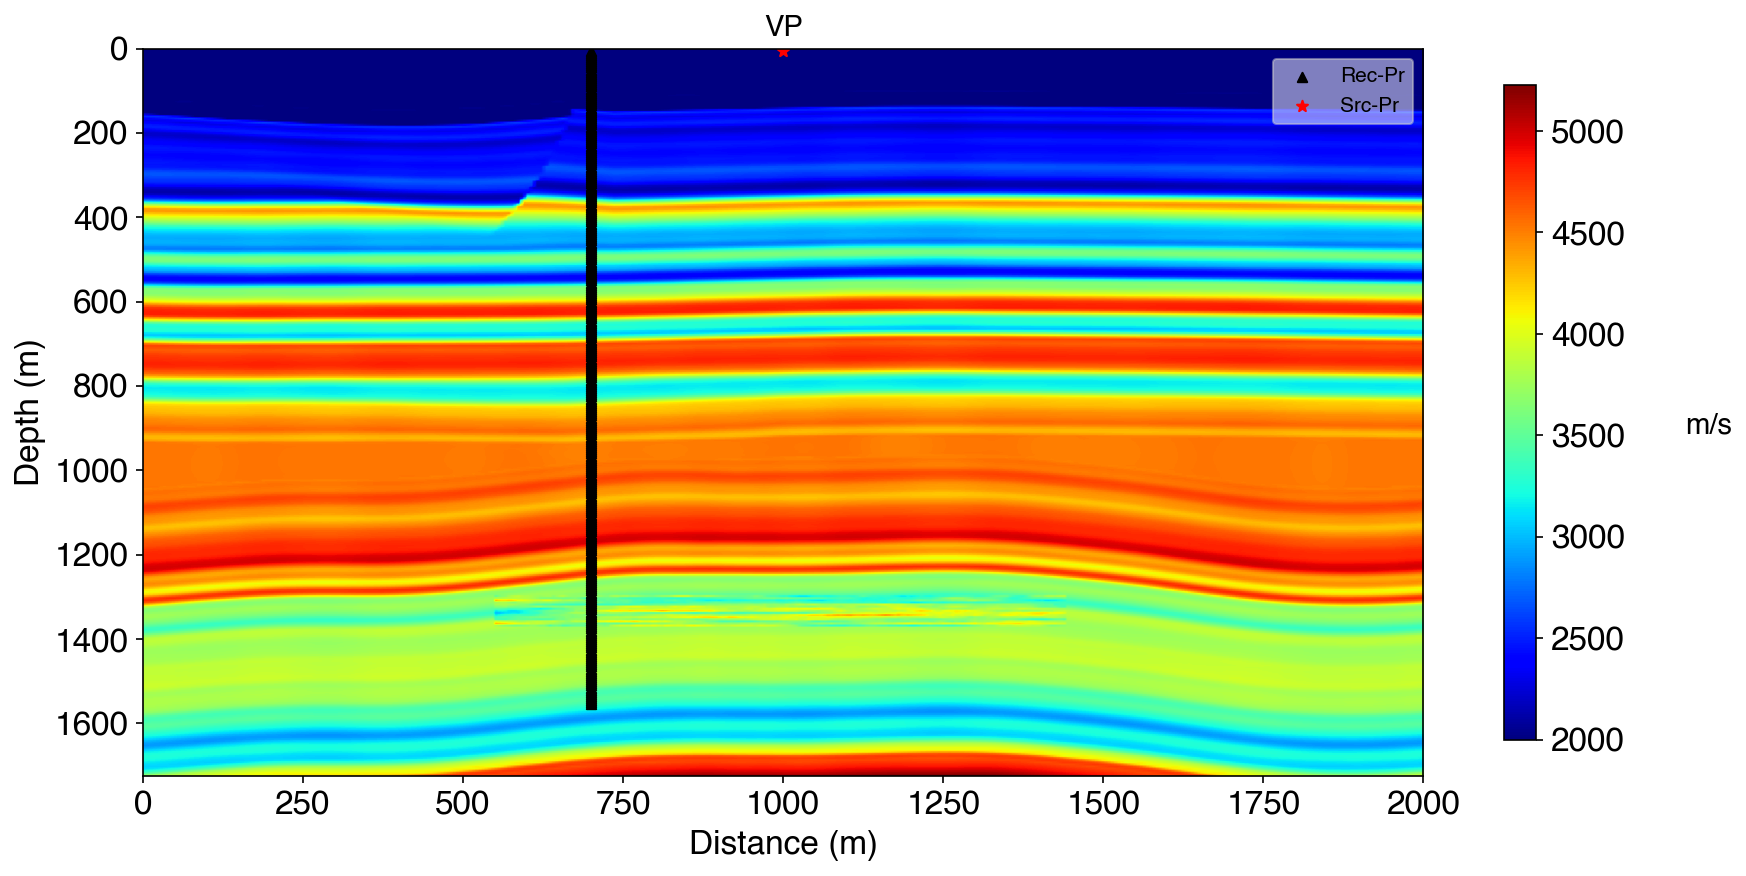

In [134]:
model_bl.plot(survey, cmap='jet', orientation='vertical', figsize=(12, 6))

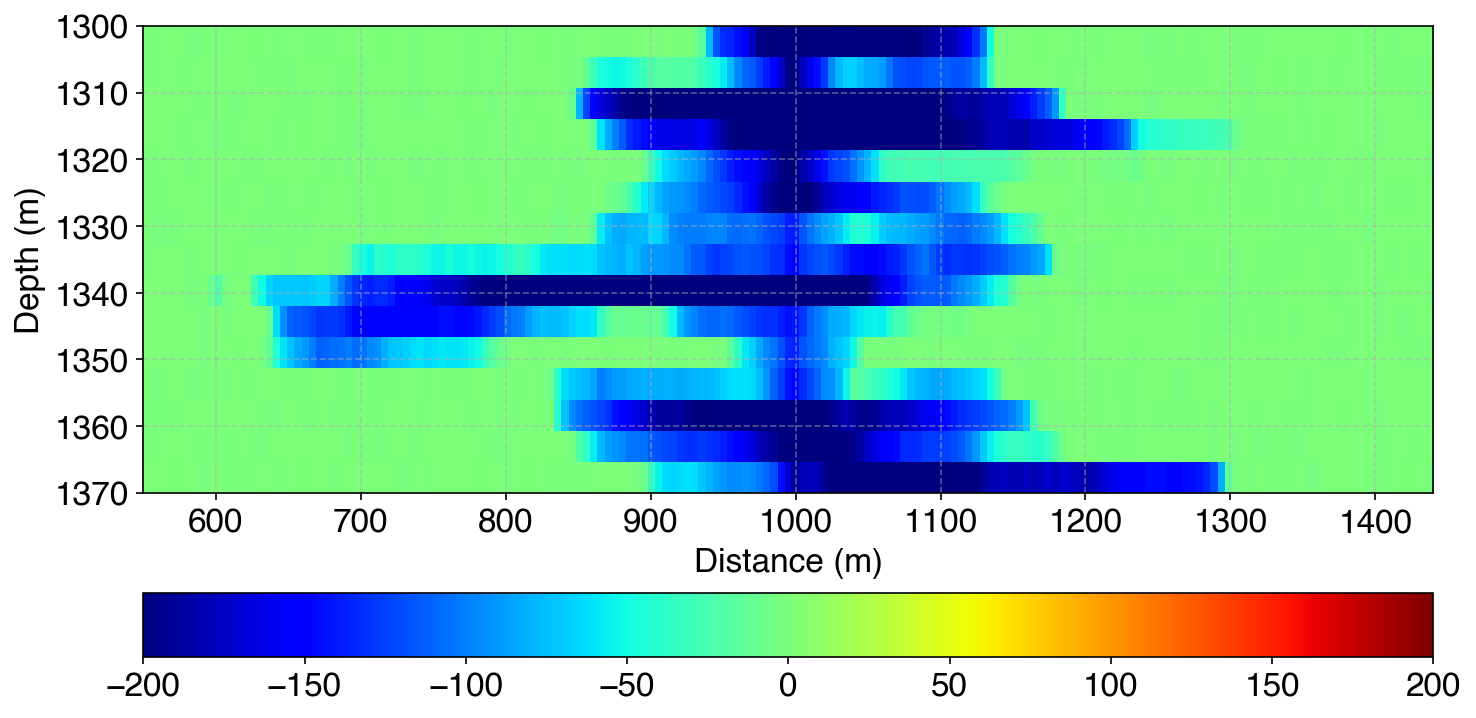

In [135]:
plot_2d(x_res, z_res, vp_obs, vmin=-200, vmax=200, cmap='jet')

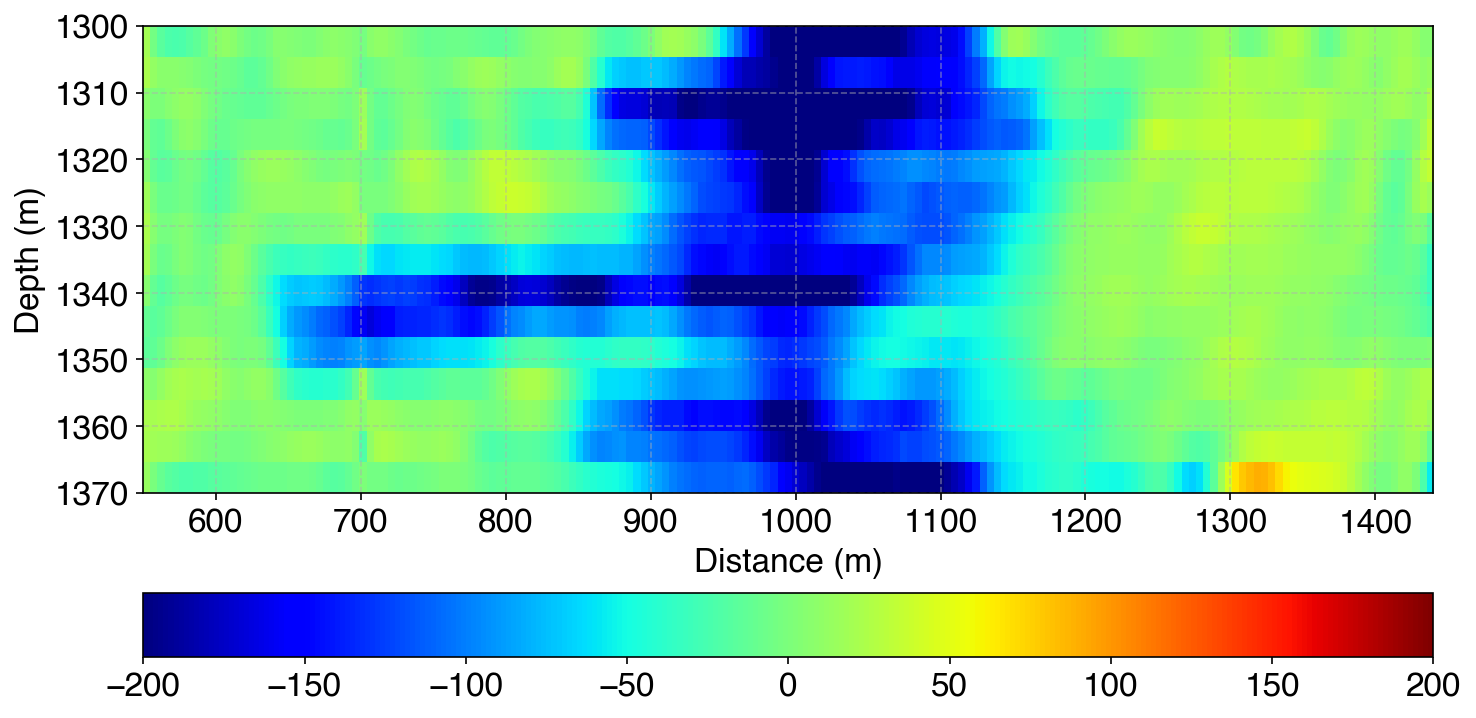

In [136]:
plot_2d(x_res, z_res, vp_fwi, vmin=-200, vmax=200, cmap='jet')

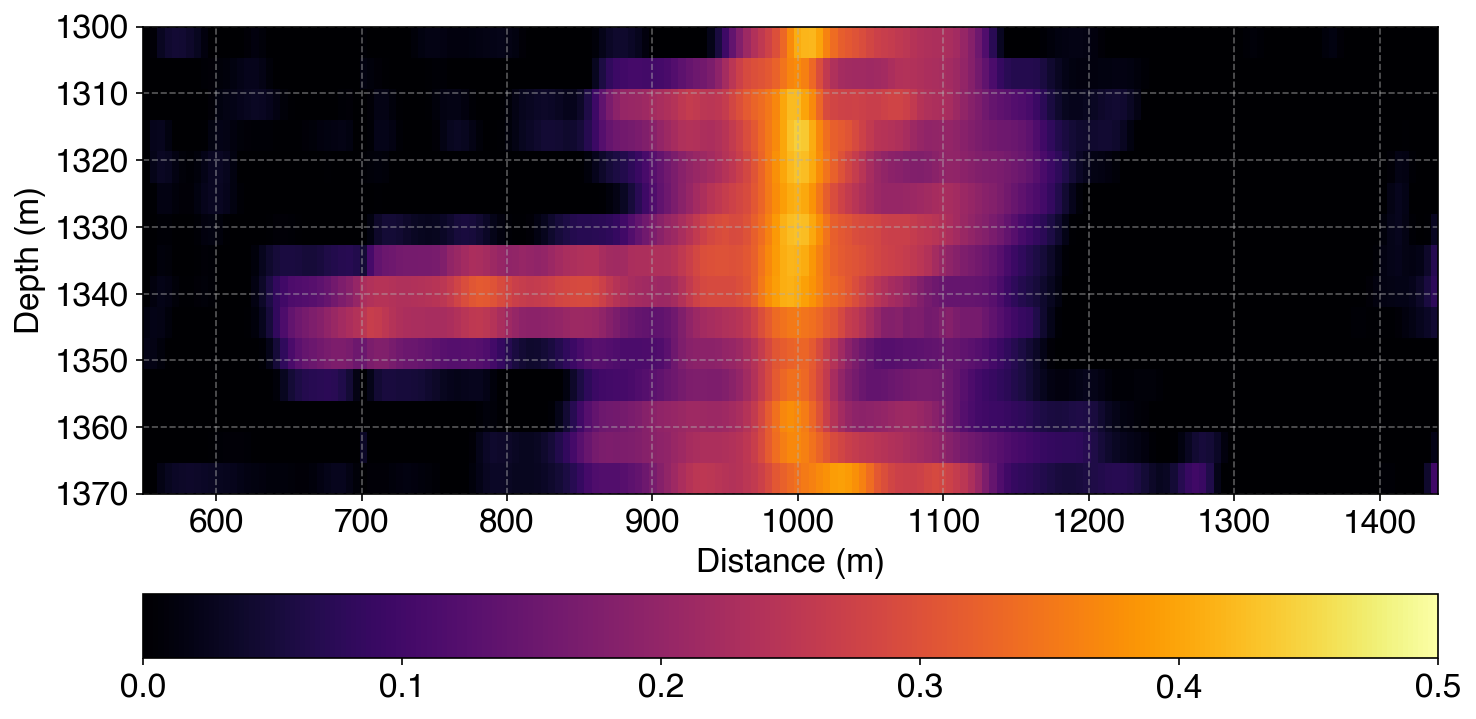

In [137]:
plot_2d(x_res, z_res, sa_fwi_inv, vmin=0, vmax=0.5, cmap='inferno')

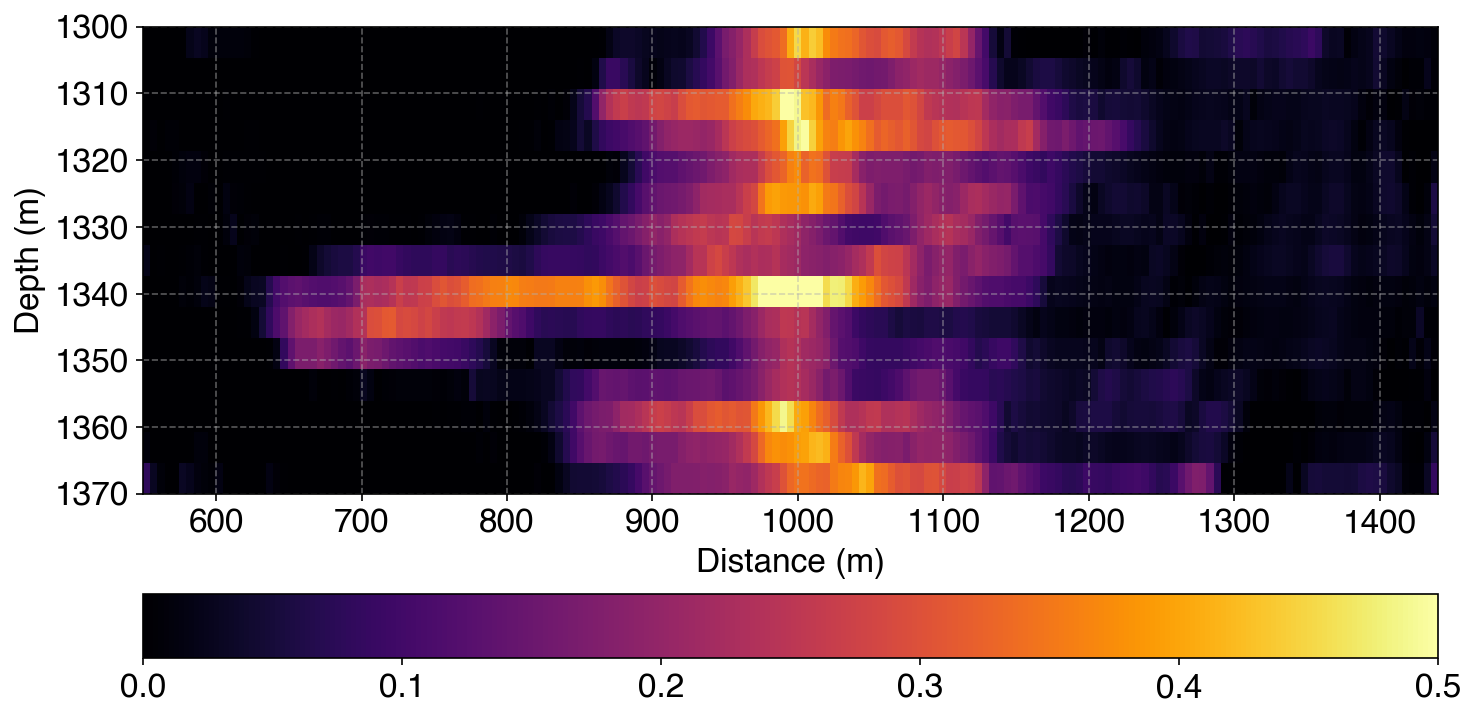

In [138]:
plot_2d(x_res, z_res, sa_fwi, vmin=0, vmax=0.5, cmap='inferno')

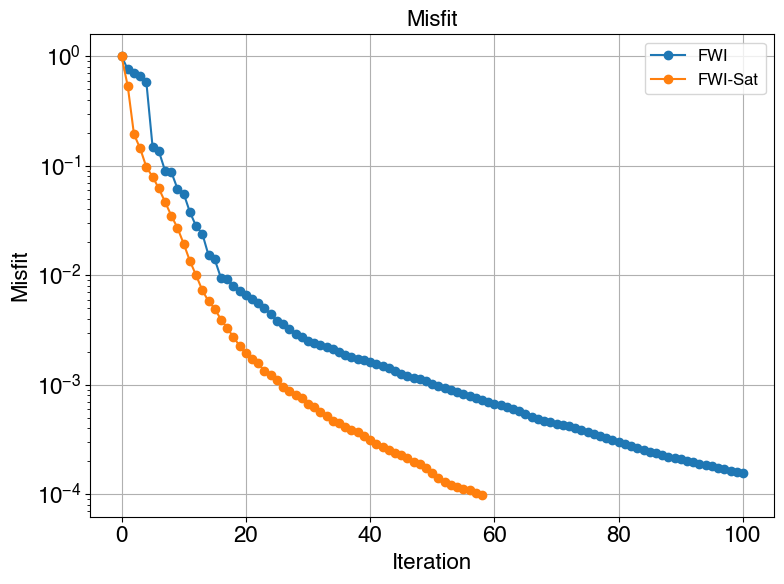

In [139]:
misfit_fd  = load_log_file(path/'FWI.log')
misfit_sat = load_log_file(path/'FWI-Sat.log')

plot_misfit([misfit_fd['fk'].values, misfit_sat['fk'].values], label=['FWI', 'FWI-Sat'], figsize=(8,6))

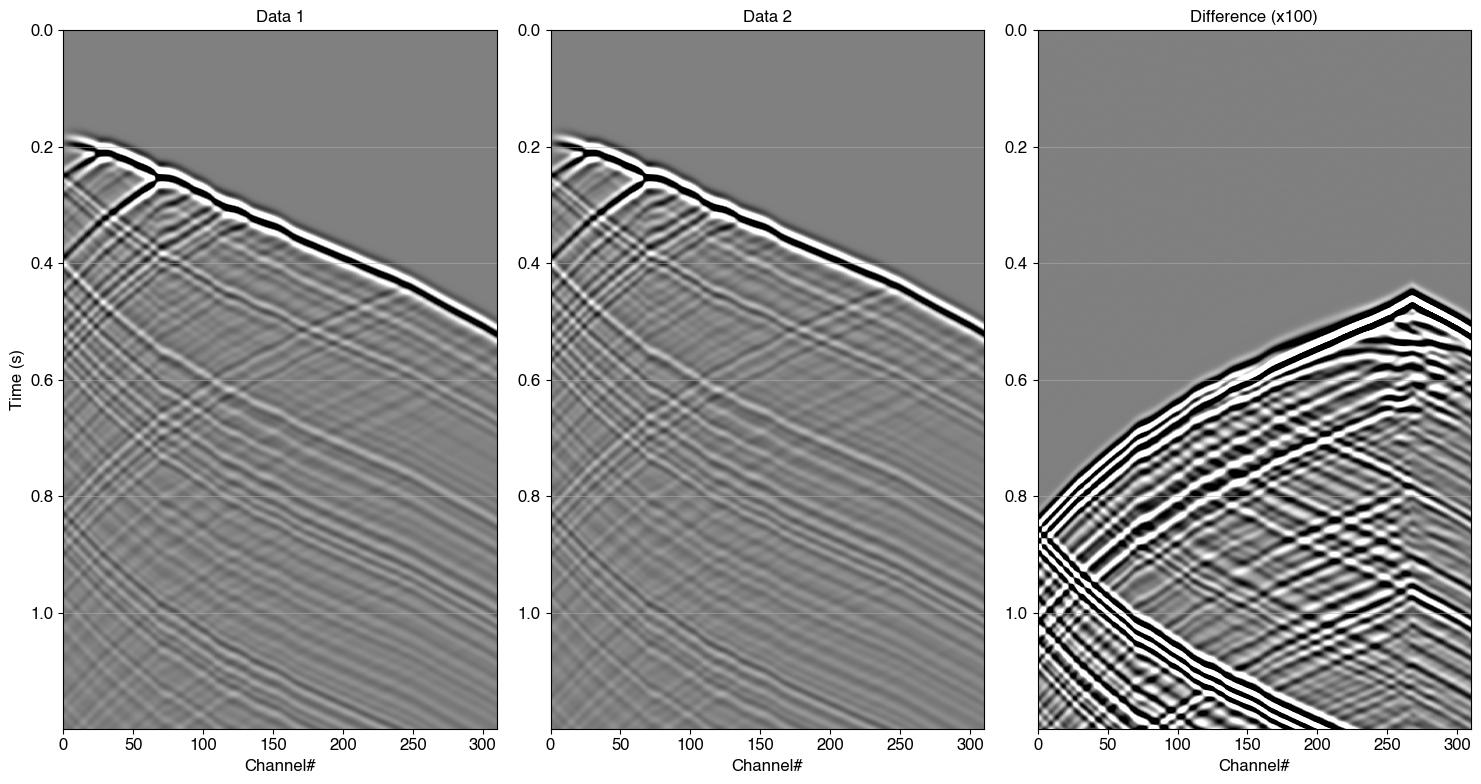

In [140]:
dobs_bl_clean = SeismicData.load(f'{path}/dobs-BL.npz')
dobs_ml_clean = SeismicData.load(f'{path}/dobs-ML.npz')
dobs_ml_clean.plot_compare(dobs_bl_clean, comp=['pr'], ratio=100, pclip=99)

### Bayesian FWI 

In [141]:
# HMC parameters
num_samples = 40000
hmc_temp = 0.025

In [142]:
!ls $path/HMC

LogProb-hmc-num-40000-temp-0.025.npy	 Posterior-hmc-num-40000-temp-0.025.nc
Posterior-hmc-num-40000-temp-0.025.json  Prior-hmc-num-40000-temp-0.025.npy


In [143]:
path

PosixPath('/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-3-geophone-1-30Hz')

In [144]:
latent_prior        = np.load(       path / f"HMC/Prior-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
log_prob            = np.load(       path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
latent_posterior    = latent_posterior_az.posterior['m'].values[0]

In [145]:
latent_posterior_az

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

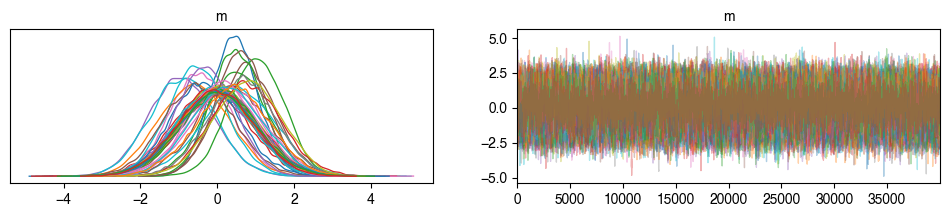

In [146]:
az.plot_trace(latent_posterior_az, var_names=["m"])
None

In [147]:
summary = az.summary(latent_posterior_az, round_to=3)
summary

arviz - WARNING - Shape validation failed: input_shape: (1, 40000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m[0],0.015,1.015,-1.884,1.863,0.036,0.026,787.304,1963.547,NaN
m[1],0.031,0.995,-1.874,1.876,0.036,0.025,779.785,1521.997,NaN
m[2],0.502,0.804,-1.087,1.931,0.027,0.019,860.955,2128.152,NaN
m[3],-0.189,0.983,-2.022,1.658,0.032,0.022,966.674,1872.656,NaN
m[4],-0.929,0.858,-2.565,0.648,0.026,0.019,1050.983,2197.404,NaN
...,...,...,...,...,...,...,...,...,...
m[59],0.263,0.947,-1.543,1.994,0.029,0.020,1101.061,2319.800,NaN
m[60],0.020,1.011,-1.830,1.971,0.033,0.023,950.073,1628.957,NaN
m[61],0.395,0.957,-1.416,2.200,0.033,0.023,856.384,1666.826,NaN
m[62],-0.022,1.021,-1.971,1.854,0.036,0.025,821.018,1766.768,NaN


In [148]:
sd = summary["sd"].values              # shape (64,)
mcse_sd = summary["mcse_sd"].values    # shape (64,)
ratio = mcse_sd / sd                   # relative MC error
print(f"ratio min/median/max: {ratio.min():.4f}  {np.median(ratio):.4f}  {ratio.max():.4f}")

ratio min/median/max: 0.0176  0.0232  0.0271


### Latent Space

### Saturation model

In [149]:
# Load VAE Model
kld_weight = 0.000015
in_channels = 1
latent_dim = 64
device = torch.device(defaults.device)
checkpoint_path = f"/net/vision/scr2/haipeng/FWI-HMC/VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

# Reload the model
model_vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(defaults.device)
model_vae.load_state_dict(torch.load(checkpoint_path, map_location=defaults.device))
model_vae.eval()

def decode_in_batches(model, latent_tensor, batch_size):
    """Decode latent vectors in batches to avoid GPU OOM."""
    decoded = []
    n_samples = latent_tensor.shape[0]

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Decoding batches"):
            batch = latent_tensor[i:i + batch_size]
            decoded_batch = model.decode(batch)
            decoded_batch = F.interpolate(decoded_batch, size=(15, 179), mode='bilinear', align_corners=False)
            decoded.append(decoded_batch.cpu())
            
    decoded = torch.cat(decoded, dim=0)
    # compute mean, std, p10, p50, p90
    p10 = torch.quantile(decoded, 0.1, dim=0).numpy().squeeze()
    p50 = torch.quantile(decoded, 0.5, dim=0).numpy().squeeze()
    p90 = torch.quantile(decoded, 0.9, dim=0).numpy().squeeze()
    mean = torch.mean(decoded, dim=0).numpy().squeeze()
    std = torch.std(decoded, dim=0).numpy().squeeze()
    
    decoded = decoded.numpy().squeeze()

    return decoded, mean, std, p10, p50, p90

In [150]:
# Convert to tensor and move to device
latent_prior_tensor     = torch.as_tensor(latent_prior, dtype=torch.float32, device=device)
latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)

# Run batched decoding
sa_prior, sa_prior_mean, sa_prior_std, sa_prior_p10, sa_prior_p50, sa_prior_p90 = decode_in_batches(model_vae, latent_prior_tensor, 512)
sa_post , sa_post_mean,  sa_post_std,  sa_post_p10,  sa_post_p50,  sa_post_p90  = decode_in_batches(model_vae, latent_posterior_tensor, 512)

# Find MAP sample
map_id = np.argmax(log_prob)
sa_map = sa_post[map_id]

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 46.72it/s]


In [151]:
# Load the true saturation
sa_obs = np.load('model/sa_res_nz15_nx179_5m.npy')

# coordinates for plotting
dx, dz = 5.0, 5.0 
nz_sat, nx_sat = 15, 179
res_x = np.arange(nx_sat) * dx + 110 * dx
res_z = np.arange(nz_sat) * dz + 260 * dz
extent_res = [res_x[0]/1000, res_x[-1]/1000, res_z[-1]-res_z[0], 0]

vp_fwi = vp_fwi[260:260+nz_sat, 110:110+nx_sat]
vp_obs = vp_obs[260:260+nz_sat, 110:110+nx_sat]

### Clustering the results

In [152]:
panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)"]

In [153]:
# top 10% count
n_top = int(0.1 * len(log_prob))
top_indices = np.argsort(log_prob)[::-1][:n_top]
sa_posterior_top_10 = sa_post[top_indices]

rep_models = [sa_posterior_top_10[idx] for idx in [0, 5, 10, 15]]

In [154]:
15/40000

0.000375

/tmp/ipykernel_8880/3167636180.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space at right for colorbar


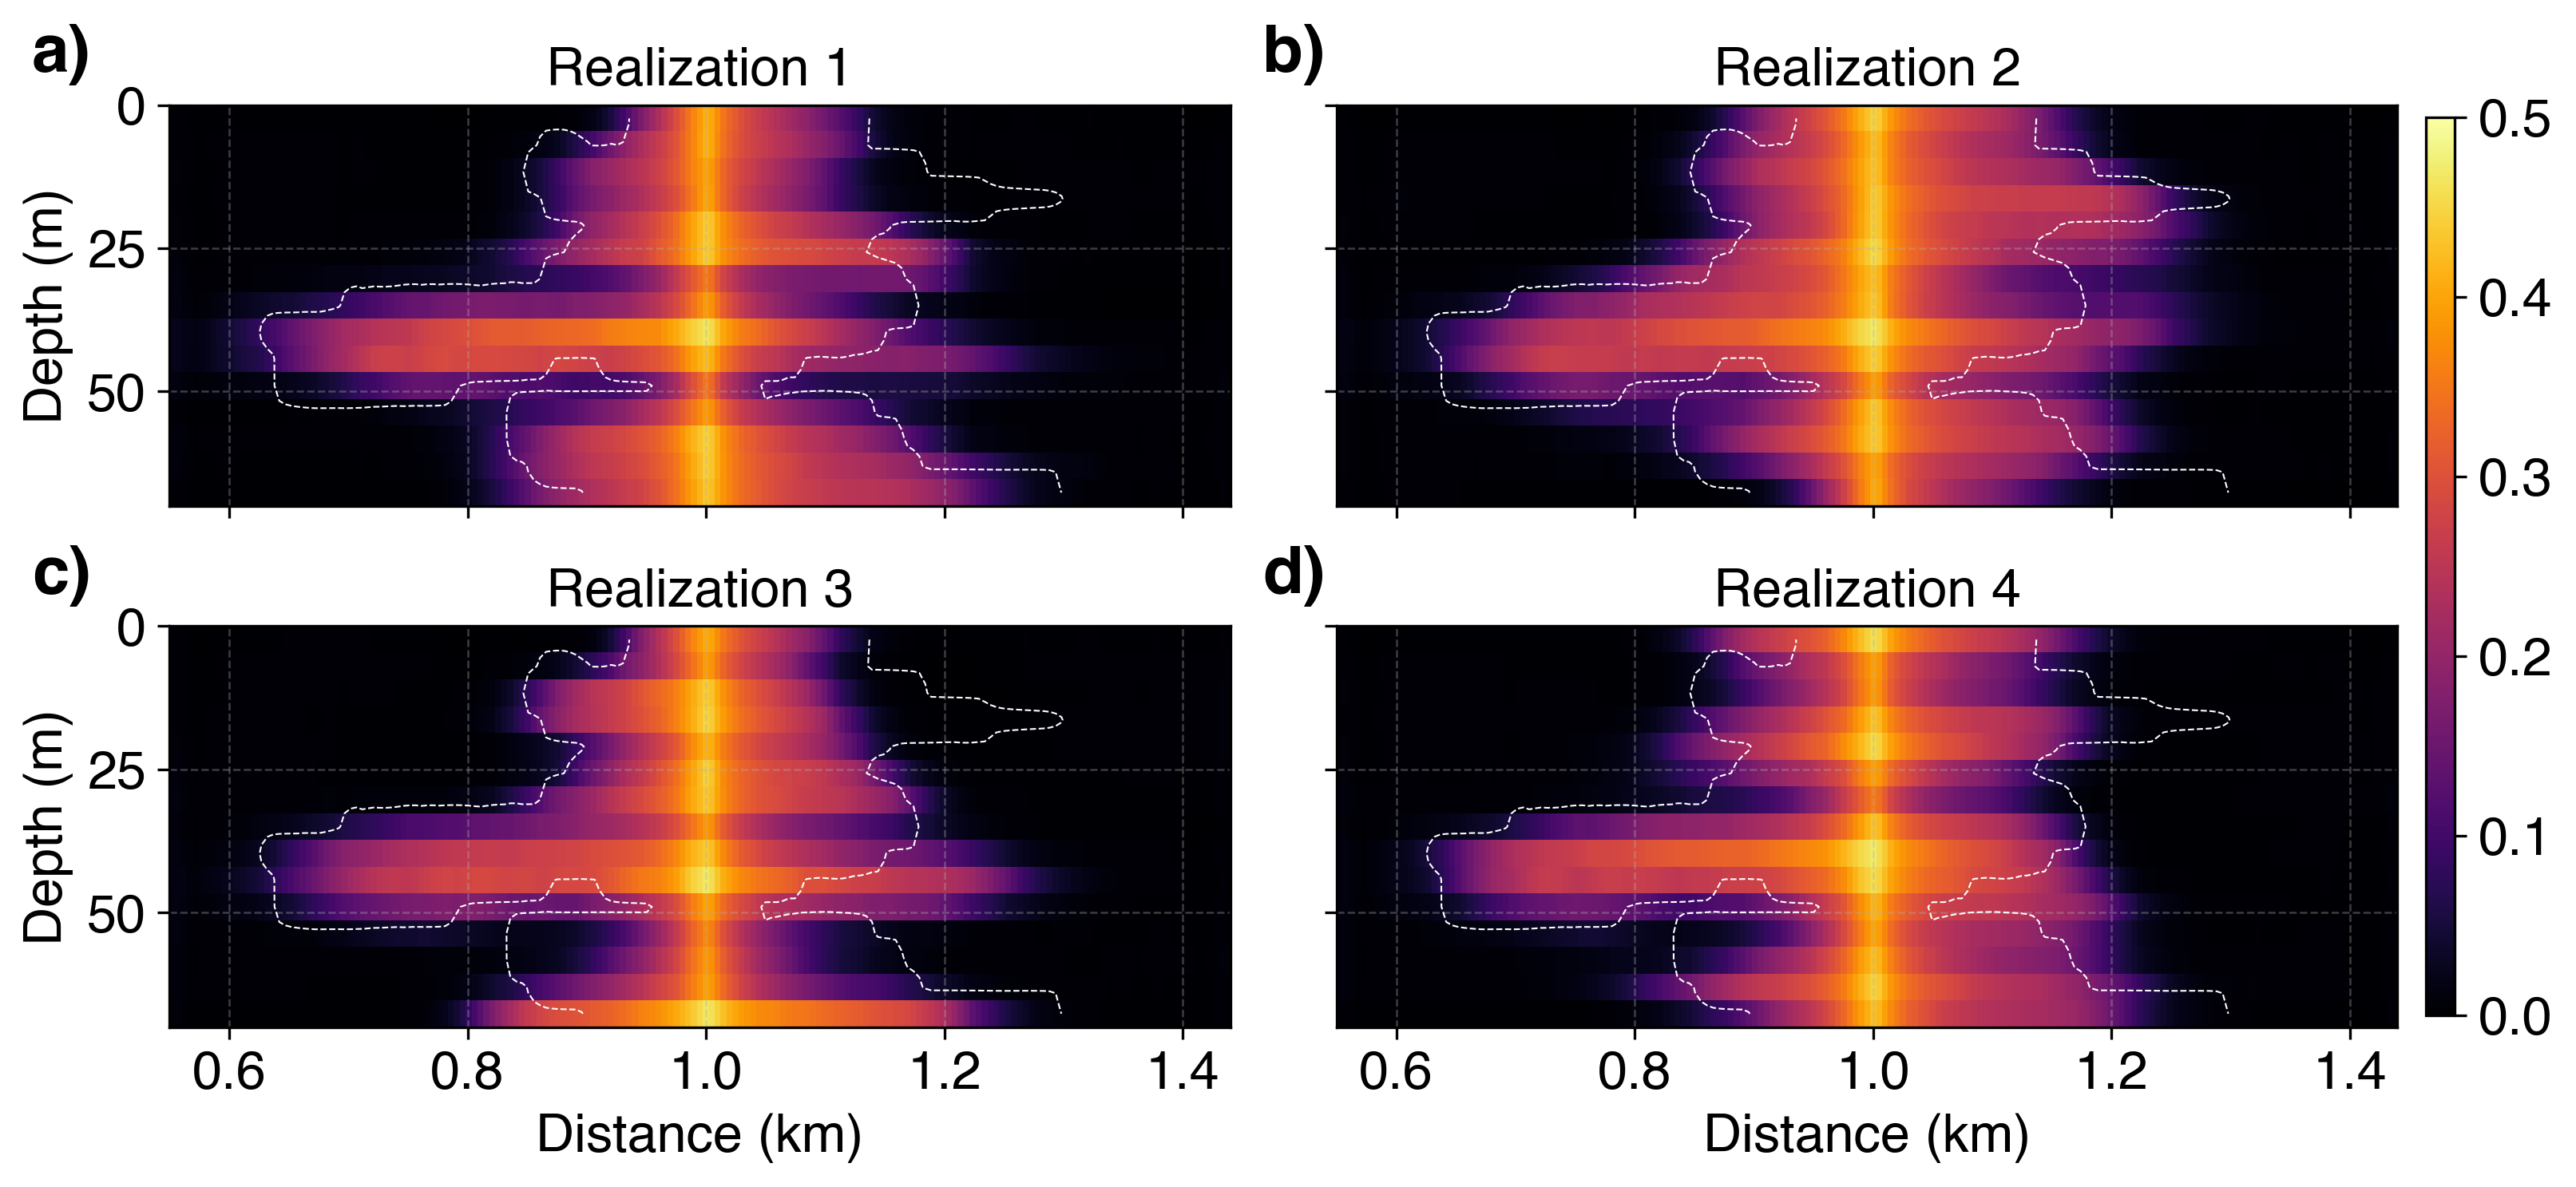

In [155]:
# ---------- Style ----------
fontsize = 16
plt.rcParams.update({
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# ---------- Plot the 4 cluster centroids in 2x2 ----------
nrows, ncols = 2, 2
fig = plt.figure(figsize=(12, 5), dpi=300)  # slightly wider for colorbar
gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.3, wspace=0.1)
im_axes = []

for i, sa_ in enumerate(rep_models):   # rep_models is (4, nz, nx) from clustering
    row, col = divmod(i, ncols)
    ax = fig.add_subplot(gs[row, col])
    im = ax.imshow(sa_, cmap="inferno", aspect="auto", vmin=0, vmax=0.5, extent=extent_res)
    ax.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')

    # Labels only on bottom row and left col
    if row == nrows - 1:
        ax.set_xlabel("Distance (km)", fontsize=fontsize)
    else:
        ax.set_xticklabels([])

    if col == 0:
        ax.set_ylabel("Depth (m)", fontsize=fontsize)
    else:
        ax.set_yticklabels([])

    ax.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax.set_title(f"Realization {i+1}", fontsize=fontsize)
    im_axes.append(im)
    if i in [0, 2]:
        ax.text(-0.13, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, ha="left", va="bottom", fontweight="bold")
    else:
        ax.text(-0.07, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, ha="left", va="bottom", fontweight="bold")
    

# ---------- Shared colorbar on the right ----------
cbar_ax = fig.add_axes([0.91, 0.12, 0.01, 0.75])  # [left, bottom, width, height]
cbar = fig.colorbar(im_axes[0], cax=cbar_ax, orientation="vertical")
cbar.ax.tick_params(labelsize=fontsize)
cbar.minorticks_off()

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space at right for colorbar
plt.savefig(f"figures_revision/FWI-HMC-Sparse-Model-Top-Source-{src_id}.png", dpi=300, bbox_inches="tight")
plt.show()

### Forward Modeling

In [156]:
from seisfwi.model import AcousticModelSaturation
from seisfwi.propagator import AcousticPropagator

In [157]:
dobs_bl = SeismicData.load(f'{path}/dobs-BL.npz').data['pr'].cpu().numpy().squeeze()
dobs_ml = SeismicData.load(f'{path}/dobs-ML.npz').data['pr'].cpu().numpy().squeeze()

In [158]:
ox, oz = model_bl.ox, model_bl.oz
nx, nz = model_bl.nx, model_bl.nz
dx, dz = model_bl.dx, model_bl.dz
free_surface = model_bl.free_surface
vp_bl = model_bl.get_model('vp')

In [159]:
F = AcousticPropagator(model_bl, survey)

2026-03-09 20:30:11,784 - INFO - Survey analysis completed: all sources and receivers within model range.


In [160]:
dfwi_all = []

for sat in rep_models:
    model_fwi = AcousticModelSaturation(ox, oz, dx, dz, nx, nz, rock_physics_params, vp_bl, sat = sat, free_surface=free_surface)
    d = F(model_fwi).data['pr'].cpu().numpy().squeeze()
    dfwi_all.append(d)


In [161]:
print(survey.receiver_pr_loc[:, 150])
print(survey.receiver_pr_loc[:, 300])

[[700. 755.]]
[[ 700. 1505.]]


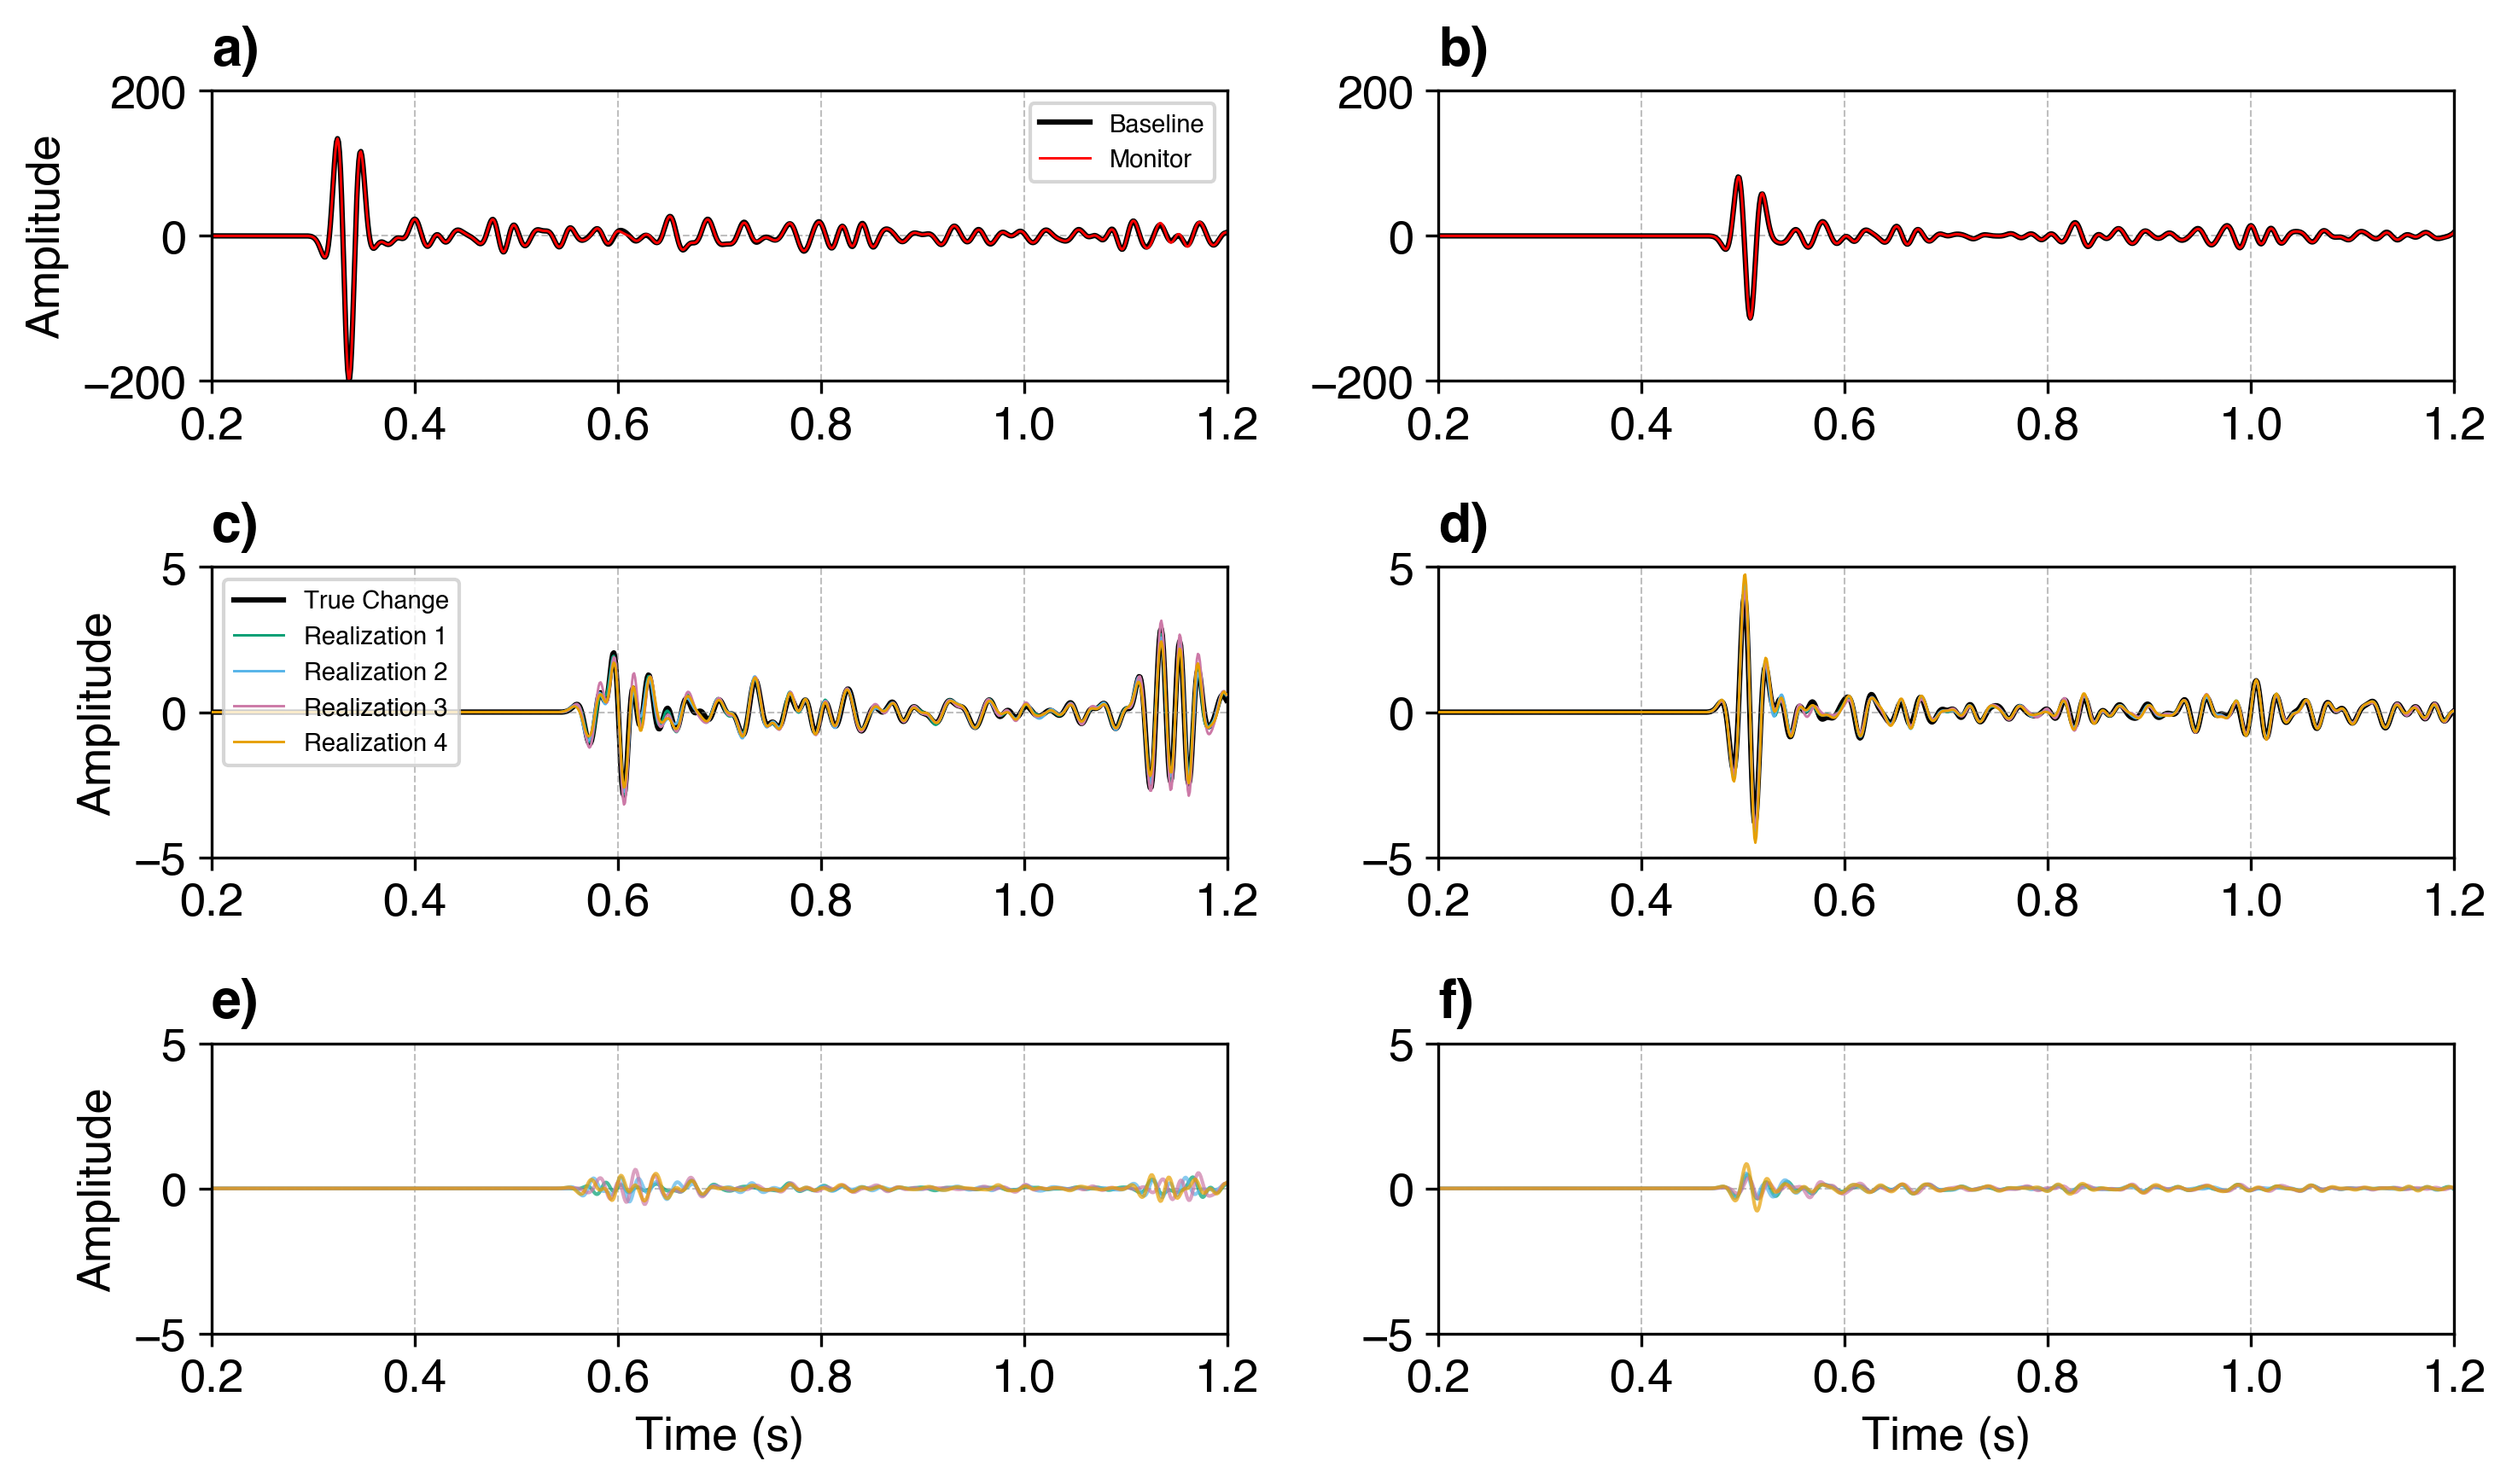

In [162]:
# ---------- Style ----------
fontsize = 13
plt.rcParams.update({
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})


trace_ids = [150, 300]
nt = 1200
dt = 0.001
t = np.arange(nt) * dt

# Create a 3x3 grid figure: Raw Data | Time-Lapse | Residuals
fig, axes = plt.subplots(3, len(trace_ids), figsize=(10, 6), sharex=False, dpi=300)

# Colors for the different posterior samples (up to 6 distinct colors)
sample_colors = [
    "#009E73",
    "#56B4E9",
    "#CC79A7",
    "#E69F00"
]

for i, trace in enumerate(trace_ids):
    ax_raw = axes[0, i]
    ax_tl = axes[1, i]
    ax_res = axes[2, i]
    
    # RAW DATA PANEL (Left)
    ax_raw.plot(t, dobs_bl[trace], label="Baseline", color="black", linewidth=1.5)
    ax_raw.plot(t, dobs_ml[trace], label="Monitor", color="red", linewidth=0.7)
    
    # TIME-LAPSE OVERLAY PANEL (Middle)
    true_tl = dobs_ml[trace] - dobs_bl[trace]
    ax_tl.plot(t, true_tl, label="True Change", color="k", linewidth=1.5, zorder=1)
    
    # POSTERIOR SAMPLES & RESIDUALS
    for j, dfwi in enumerate(dfwi_all):
        modeled_tl = dfwi[trace] - dobs_bl[trace]
        residual = modeled_tl - true_tl
        
        c = sample_colors[j % len(sample_colors)]
        label_wave = f"Realization {j+1}" if i == 0 else None
        ax_tl.plot(t, modeled_tl, label=label_wave, color=c, alpha=1, linewidth=0.7, zorder=j+2)
        ax_res.plot(t, residual, color=c, alpha=0.7, linewidth=1.0)

    for ax in [ax_raw, ax_tl, ax_res]:
        ax.grid(True, linestyle="--", alpha=0.5, linewidth=0.5, color='gray')
    
    # Set y-limits (You may need to adjust these based on your actual data amplitudes)
    ax_raw.set_ylim([-200, 200])
    ax_raw.set_xlim(0.2, 1.2)

    ax_tl.set_ylim([-5, 5])
    ax_tl.set_xlim([0.2, 1.2])

    ax_res.set_ylim([-5, 5])
    ax_res.set_xlim([0.2, 1.2])

# Set Legends
axes[0, 0].legend(frameon=True, loc="upper right", fontsize=7)
axes[1, 0].legend(frameon=True, loc="upper left", fontsize=7, ncol=1)

# Set X-axis labels and limits
for j in range(2):
    axes[-1, j].set_xlabel("Time (s)")

for j in range(3):
    axes[j, 0].set_ylabel("Amplitude")

axes[0, 0].text(-0.0, 1.05, 'a)', transform=axes[0, 0].transAxes, fontsize=15, ha="left", va="bottom", fontweight="bold")
axes[0, 1].text(-0.0, 1.05, 'b)', transform=axes[0, 1].transAxes, fontsize=15, ha="left", va="bottom", fontweight="bold")
axes[1, 0].text(-0.0, 1.05, 'c)', transform=axes[1, 0].transAxes, fontsize=15, ha="left", va="bottom", fontweight="bold")
axes[1, 1].text(-0.0, 1.05, 'd)', transform=axes[1, 1].transAxes, fontsize=15, ha="left", va="bottom", fontweight="bold")
axes[2, 0].text(-0.0, 1.05, 'e)', transform=axes[2, 0].transAxes, fontsize=15, ha="left", va="bottom", fontweight="bold")
axes[2, 1].text(-0.0, 1.05, 'f)', transform=axes[2, 1].transAxes, fontsize=15, ha="left", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(f"figures_revision/FWI-HMC-Sparse-Waveform-Top-Source-{src_id}.png", dpi=300, bbox_inches="tight")
plt.show()

In [163]:
# top 10% count
n_top = int(0.1 * len(log_prob))
top_indices = np.argsort(log_prob)[::-1][:n_top]
sa_posterior_top_10 = sa_post[top_indices].reshape(n_top, -1)

# run KMeans on top 10% samples
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(sa_posterior_top_10)

# identify medoids (representatives)
medoids = []
for i in range(k):
    cluster_idx = np.where(labels == i)[0]
    cluster_points = sa_posterior_top_10[cluster_idx]
    centroid = kmeans.cluster_centers_[i].reshape(1, -1)
    dists = pairwise_distances(cluster_points, centroid)
    medoid_idx = cluster_idx[np.argmin(dists)]
    medoids.append(medoid_idx)

# representative models (still flattened)
rep_models_flat = sa_posterior_top_10[medoids]

# reshape back to (nz, nx) for interpretation
rep_models = rep_models_flat.reshape(k, nz_sat, nx_sat)

# cluster weights (relative importance of each representative scenario)
cluster_weights = np.bincount(labels) / len(labels)

print("Cluster weights:", cluster_weights)

Cluster weights: [0.201  0.294  0.2605 0.2445]


In [164]:
cluster_weights = [round(w, 2) for w in cluster_weights]
panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)"]
cluster_weights

[0.2, 0.29, 0.26, 0.24]

/tmp/ipykernel_8880/3656636826.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space at right for colorbar


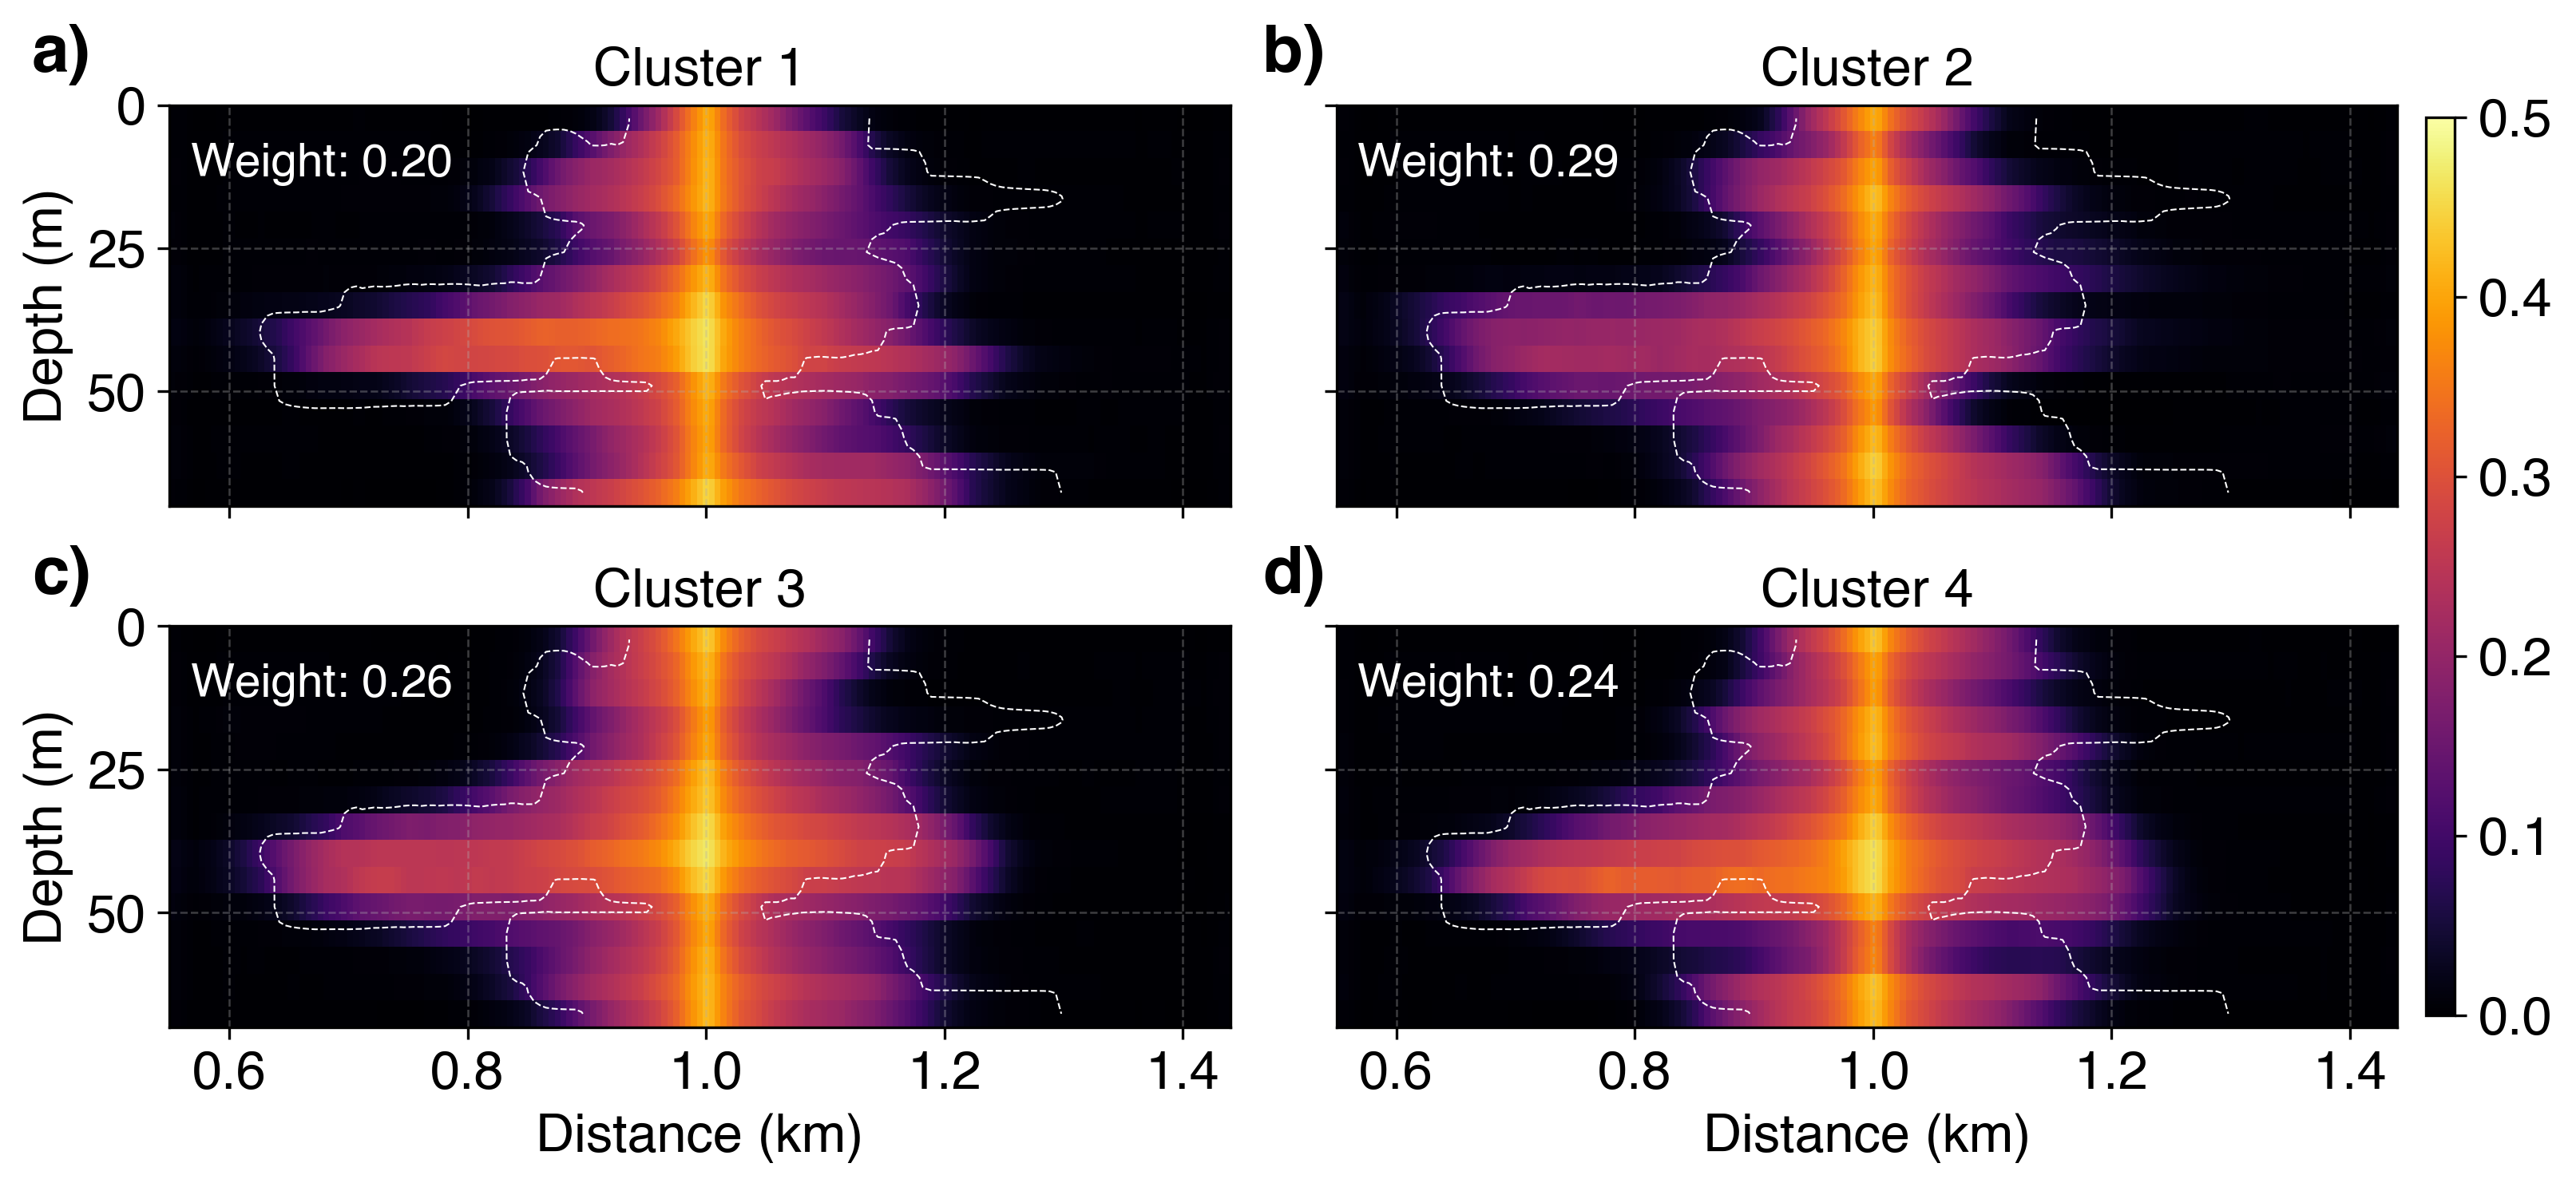

In [165]:
# ---------- Style ----------
fontsize = 16
plt.rcParams.update({
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# ---------- Plot the 4 cluster centroids in 2x2 ----------
nrows, ncols = 2, 2
fig = plt.figure(figsize=(12, 5), dpi=300)  # slightly wider for colorbar
gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.3, wspace=0.1)
im_axes = []

for i, sa_ in enumerate(rep_models):   # rep_models is (4, nz, nx) from clustering
    row, col = divmod(i, ncols)
    ax = fig.add_subplot(gs[row, col])
    im = ax.imshow(sa_, cmap="inferno", aspect="auto", vmin=0, vmax=0.5, extent=extent_res)
    # ax.text(0.0, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, fontweight="bold", ha="left", va="bottom")
    ax.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')

    # Labels only on bottom row and left col
    if row == nrows - 1:
        ax.set_xlabel("Distance (km)", fontsize=fontsize)
        # ax.set_xticks(np.arange(0.6, res_x[-1]/1000+0.2, 0.2))
        # ax.set_yticks(np.arange(0.80, 0.88, 0.02))
    else:
        ax.set_xticklabels([])

    if col == 0:
        ax.set_ylabel("Depth (m)", fontsize=fontsize)
        # ax.set_yticks(np.arange(res_z[0]/1000, res_z[-1]/1000, 0.02))
    else:
        ax.set_yticklabels([])

    ax.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax.set_title(f"Cluster {i+1}", fontsize=fontsize)
    im_axes.append(im)
    if i in [0, 2]:
        ax.text(-0.13, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, ha="left", va="bottom", fontweight="bold")
    else:
        ax.text(-0.07, 1.05, panel_labels[i], transform=ax.transAxes, fontsize=20, ha="left", va="bottom", fontweight="bold")
    
    ax.text(0.02, 0.8, f"Weight: {cluster_weights[i]:.2f}", transform=ax.transAxes, fontsize=14, ha="left", va="bottom", color='w')

# ---------- Shared colorbar on the right ----------
cbar_ax = fig.add_axes([0.91, 0.12, 0.01, 0.75])  # [left, bottom, width, height]
cbar = fig.colorbar(im_axes[0], cax=cbar_ax, orientation="vertical")
cbar.ax.tick_params(labelsize=fontsize)
cbar.minorticks_off()

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space at right for colorbar
plt.savefig(f"figures_revision/FWI-HMC-Sparse-Cluster-Top-Source-{src_id}.png", dpi=300, bbox_inches="tight")
plt.show()